Name: Shawn June
Worked with: None

# Lab 01: Data wrangling and EDA

**You should add this to a personal Github repo and submit the link to the repo in Canvas.** Add your name to the top of this document and anyone you worked with.

The goal of this lab is to practice working with datasets using Pandas and explore a dataset with plotting and basic statistics. In particular, we will look at a plot to track flows (association between two categoricals): the alluvial diagram.

Here is your lab prompt: You are advising the University of Virginia’s Office of Development on opportunities to expand philanthropic support from international sources. Using the foreign-giving data provided, develop a short strategic plan identifying the countries, institutions, or donor segments UVA should prioritize for future engagement.

Your recommendations should be evidence-based. Use the data to identify patterns in giving, compare potential sources of support, and explain why particular markets or institutions appear especially promising. Support your conclusions with appropriate summaries and visualizations, and translate your findings into a small set of concrete recommendations for the Director of Development.,

1. In your first .ipynb or .py file called **initial_analysis** complete the following steps:
     1. Load the Foreign Gifts data.
     2. Describe the differences between different classes of gift types.
     3. Answer the following questions:
         1. Which country gives the most money in total?
         2. Which country initiates the most gifts by count?
         3. Which country gives the largest gifts on average?
         4. Which institution receive the most money in total?
         5. Which institution receive the greatest number of gifts by count?
         6. What is the average amount each university receives? Median amount? If they are different why?
         7. What is the largest flow of a single country to a single institution?
         8. Which are the top giftors to US academic institutions?
 2. In a new .ipynb/.py file called **uva_analysis**, analyze foreign giving to UVA. Compare UVA to appropriate peer institutions and the market overall. Propose a strategy for finding new sources of foreign money and provide a quantitative analysis.
 3. In a document file (.doc, .docx, .pdf, etc.), summarize your findings:
     1. Executive Summary: What are your main findings and recommendations, in a single paragraph?
     2. Summarize the results of your initial analyses of overall giving and giving to UVA (1-3 paragraphs).
     3. Describe a strategy for finding new potential sources of money for UVA. What countries or institutions should UVA target, and why? (1-3 paragraphs)
     4. Conclude with a summary of UVA's prospects for increasing foreign giving. (1 paragraph).

 In total, your submission repo contain submit at least .ipynb/.py analysis files and a document file with your report (.doc, .docx, .pdf, etc.). If you divide the work among members of a group, make sure that you understand the code being written and submitted by the other members of your group.



## The standard stack: importing packages + reading in the data

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()
df['Gift Type'].value_counts()

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

The dataset contains three gift types: Contract, Monetary Gift, and Real Estate. Contracts are the most common with 17,274 records, followed by Monetary Gifts with 10,936. Real Estate is extremely uncommon, appearing only 11 times.

## Groupby

As we learned, `.groupby` is a super useful way to aggregate the data and explore summary statistics. We can assign the output to a new dataframe, just taking the n largest amounts. Resetting the index just changes the index to integers starting at 0. 

<div class="alert alert-block alert-warning">
<b>Question 1:</b>  Which country gives the most money, in total?
</div>


In [20]:
df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(10)

Country of Giftor
QATAR           2706240869
ENGLAND         1464906771
CHINA           1237952112
SAUDI ARABIA    1065205930
BERMUDA          899593972
CANADA           898160656
HONG KONG        887402529
JAPAN            655954776
SWITZERLAND      619899445
INDIA            539556490
Name: Foreign Gift Amount, dtype: int64

Answer 1: Qatar gives the most foreign gift money in total, with approximately $2.71 billion represented in the dataset.

<div class="alert alert-block alert-warning">
<b>Question 2:</b>  Which country initiates the most gifts, by count?
</div>


In [21]:
df['Country of Giftor'].value_counts().head(10)

Country of Giftor
ENGLAND         3655
CHINA           2461
CANADA          2344
JAPAN           1896
SWITZERLAND     1676
SAUDI ARABIA    1610
FRANCE          1437
GERMANY         1394
HONG KONG       1080
SOUTH KOREA      811
Name: count, dtype: int64

Answer 2: England initiates the greatest number of gifts, with 3,655 records in the dataset.

<div class="alert alert-block alert-warning">
<b>Question 3:</b>  Which country gives the largest gifts, on average?
</div>

In [22]:
df.groupby('Country of Giftor')['Foreign Gift Amount'].mean().sort_values(ascending=False).head(10)

Country of Giftor
BERMUDA     7.688837e+06
ECUADOR     3.985140e+06
QATAR       3.905109e+06
ANTIGUA     3.435545e+06
JERSEY      3.064589e+06
MOROCCO     2.740214e+06
RUSSIA      2.025462e+06
GUERNSEY    1.750000e+06
IRAQ        1.665520e+06
CYPRUS      1.562512e+06
Name: Foreign Gift Amount, dtype: float64

Answer 3: Bermuda gives the largest gifts on average, at approximately $7.69 million per gift.

## Ordering by institution

<div class="alert alert-block alert-warning">
<b>Question 4:</b>  Which institution receive the most money, in total?
</div>

<div class="alert alert-block alert-warning">
<b>Question 5:</b>  Which institution receive the greatest number of gifts, by count?
</div>

Build a plot of the top 20 institutions by the amount or number of gifts they have received using either seaborn or plotly. 

In [23]:
df.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(10)

Institution Name
Carnegie Mellon University               1477922504
Cornell University                       1289937761
Harvard University                        954803610
Massachusetts Institute of Technology     859071692
Yale University                           613441311
Texas A&M University                      521455050
Johns Hopkins University                  502409595
Northwestern University                   402316221
Georgetown University                     379950511
University of Chicago (The)               364544338
Name: Foreign Gift Amount, dtype: int64

Answer 4: Carnegie Mellon University received the most foreign gift money in total, with approximately $1.48 billion.

In [24]:
df['Institution Name'].value_counts().head(10)

Institution Name
University of California, Los Angeles          3916
California Institute of Technology             2502
Columbia University in the City of New York    1127
Ohio State University (The)                    1014
Johns Hopkins University                        899
University of Michigan - Ann Arbor              715
Stanford University                             668
Cornell University                              653
University of Pennsylvania                      625
Massachusetts Institute of Technology           582
Name: count, dtype: int64

Answer 5: The University of California, Los Angeles receives the greatest number of foreign gifts by count, with 3,916 records.

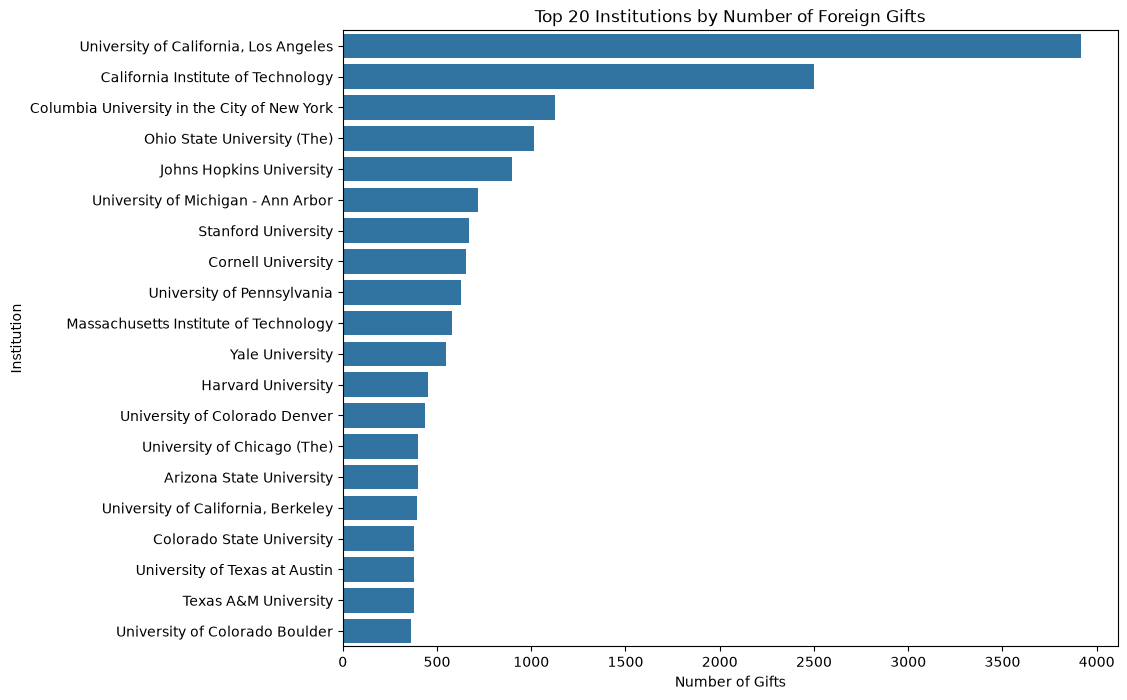

In [25]:
top20 = df['Institution Name'].value_counts().head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=top20.values, y=top20.index)
plt.xlabel('Number of Gifts')
plt.ylabel('Institution')
plt.title('Top 20 Institutions by Number of Foreign Gifts')
plt.show()

## Comparing summary statistics

<div class="alert alert-block alert-warning">
<b>Question 6:</b>  What is the average amount each university receives? Median amount? If they are different, why?
</div>

Plot a histogram of the amounts received by each university, and then label the median and the mean as vertical lines.


In [26]:
university_totals = df.groupby('Institution Name')['Foreign Gift Amount'].sum()

mean_received = university_totals.mean()
median_received = university_totals.median()

print("Mean:", mean_received)
print("Median:", median_received)

Mean: 52202878.974842764
Median: 6486791.5


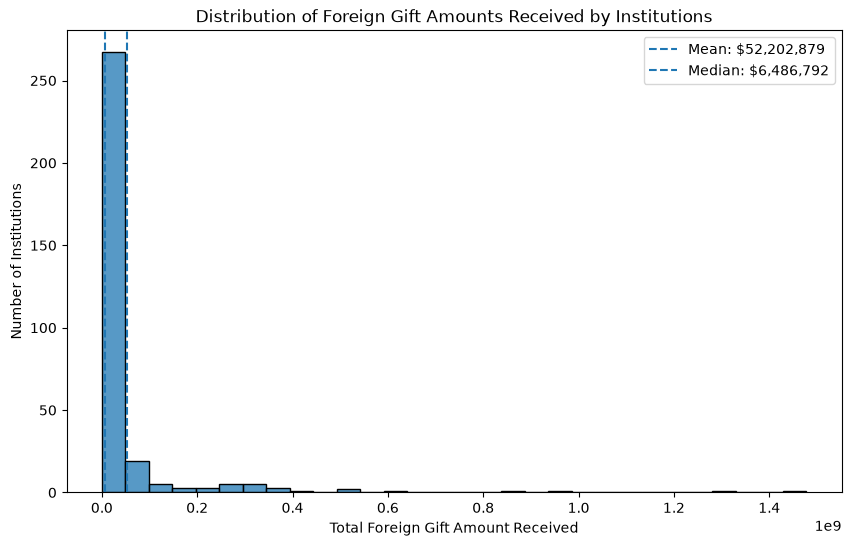

In [27]:
plt.figure(figsize=(10, 6))

sns.histplot(university_totals, bins=30)

plt.axvline(mean_received, linestyle='--', label=f'Mean: ${mean_received:,.0f}')
plt.axvline(median_received, linestyle='--', label=f'Median: ${median_received:,.0f}')

plt.xlabel('Total Foreign Gift Amount Received')
plt.ylabel('Number of Institutions')
plt.title('Distribution of Foreign Gift Amounts Received by Institutions')
plt.legend()

plt.show()

Answer 6: The mean total amount of foreign gifts received by an institution is approximately $52.20 million, while the median is approximately $6.49 million. The mean is substantially higher than the median because the distribution is strongly right-skewed: a relatively small number of institutions receive extremely large amounts of foreign funding, which pulls the mean upward. The median better represents the amount received by a typical institution.

## Relationship between variables: 
<div class="alert alert-block alert-warning">
<b>Question 7:</b>  What is the largest flow of a single country to a single institution?
</div>

### Cross-tabulation
First, use `pd.crosstab` to look at the relationship between outcoming gifts from countries and incoming gifts to institutions. 

In [28]:
country_institution_flow = (
    df.groupby(['Country of Giftor', 'Institution Name'])['Foreign Gift Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_institution_flow

Country of Giftor     Institution Name              
QATAR                 Cornell University                1018473315
BERMUDA               Carnegie Mellon University         750000000
QATAR                 Texas A&M University               504099350
                      Carnegie Mellon University         425410702
                      Georgetown University              327128310
                      Northwestern University            311148564
CANADA                Brigham Young University           259927758
UNITED ARAB EMIRATES  University of Colorado Boulder     219734835
ENGLAND               Harvard University                 188328288
HONG KONG             Yale University                    161131218
Name: Foreign Gift Amount, dtype: int64

Answer 7: The largest flow from a single country to a single institution is from Qatar to Cornell University, totaling approximately $1.02 billion.

In [29]:
df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(10)

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Name: Foreign Gift Amount, dtype: int64

### Flow of information using alluvial plots

To better visualize which countries money is flowing from and which institutions it is flowing into, we can use an alluvial diagram. There is a built-in version in plotly that we'll use.

In [30]:
import plotly.graph_objects as go

# giftor = 'Giftor Name'
# recipi = 'Institution Name'
# flor = 'Foreign Gift Amount'

giftor = 'Giftor Name'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 20

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()



<div class="alert alert-block alert-warning">
<b>Question 8:</b>  Which are the top giftors to US academic institutions?
</div>


Answer 8: Qatar Foundation is the top named giftor to U.S. academic institutions in the dataset, contributing approximately $1.17 billion.